In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

In [3]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features[:10])
print("Categorical features:", categorical_features[:10])

Numeric features: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [5]:
df.info()
df.describe()
df['OverallQual'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

- Id: numeric identifier, not useful for prediction
- MSSubClass: numeric but categorical
- OverallQual: quality score, likely important
- Neighborhood: categorical, many unique values
- Alley: many missing values

In [6]:
df['Neighborhood'].value_counts().head(10)

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
Name: count, dtype: int64

In [7]:
df['Alley'].value_counts(dropna=False)

Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [8]:
df['OverallQual'].value_counts().sort_index()

OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64

- Alley: High percentage of missing values (~80%). Indicates lack of alley access for most houses. Dropping this feature.
- Neighborhood: Categorical feature with many unique values. No major missing values. Likely strong influence on SalePrice. Keeping.
- OverallQual: Numeric, ordinal feature representing overall material and finish quality. Strong candidate feature.

In [9]:
df['LotFrontage'].isnull().sum()
df['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [10]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage']\
                        .transform(lambda x: x.fillna(x.median()))

- **LotFrontage**: Numeric feature with moderate missing values. Important for property valuation. Missing values are imputed using the median.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


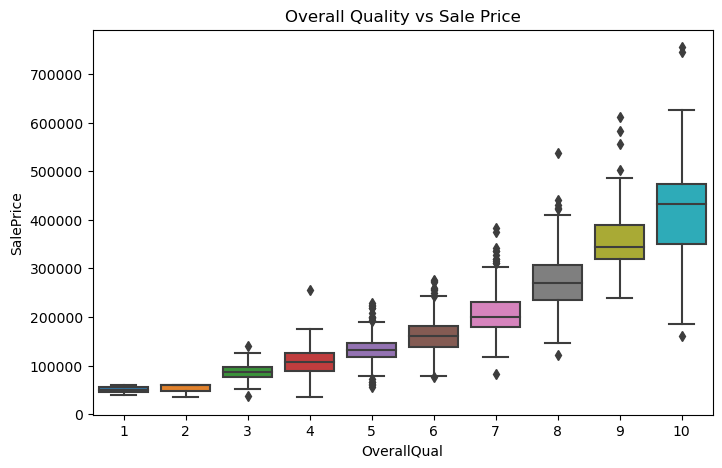

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Overall Quality vs Sale Price')
plt.show()

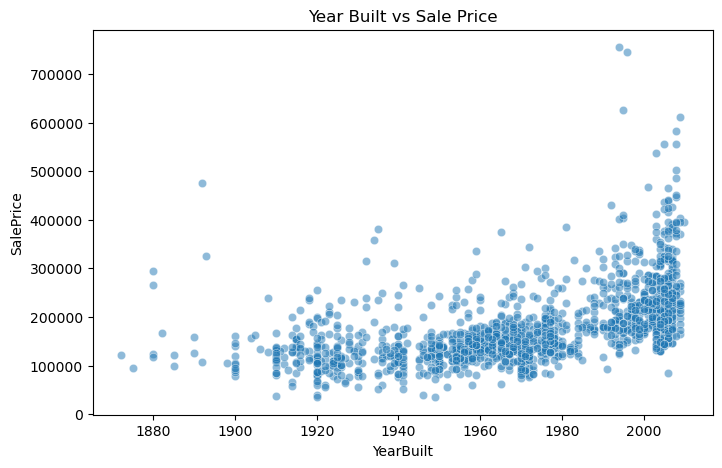

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df, alpha=0.5)
plt.title('Year Built vs Sale Price')
plt.show()

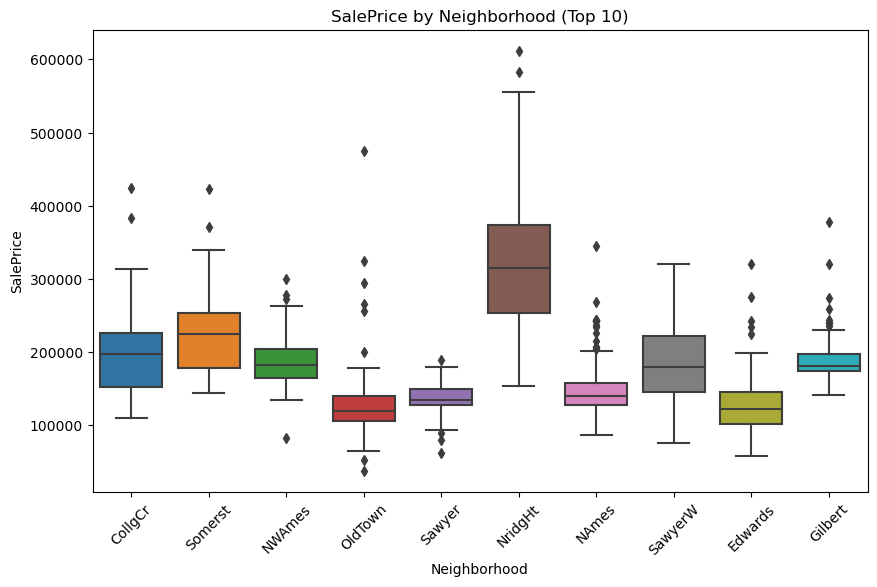

In [14]:
top_neigh = df['Neighborhood'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(x='Neighborhood', y='SalePrice',
            data=df[df['Neighborhood'].isin(top_neigh)])
plt.xticks(rotation=45)
plt.title('SalePrice by Neighborhood (Top 10)')
plt.show()

In [15]:
features = [
    'OverallQual',
    'YearBuilt',
    'LotArea',
    'LotFrontage'
]

X = df[features]
y = df['SalePrice']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 29376.55031330407
R²: 0.7031082728827618


In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
numeric_features = [
    'OverallQual',
    'YearBuilt',
    'LotArea',
    'LotFrontage'
]

categorical_features = ['Neighborhood']

In [21]:
from sklearn.compose import ColumnTransformer

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [24]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [25]:
features = ['OverallQual','YearBuilt','LotArea','LotFrontage','Neighborhood']
X = df[features]   
y = df['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
numeric_features = ['OverallQual','YearBuilt','LotArea','LotFrontage']
categorical_features = ['Neighborhood']

In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [29]:
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_val, y_pred))
print("R²:", r2_score(y_val, y_pred))

MAE: 26686.154716493944
R²: 0.760370444157521


In [30]:
ohe = model.named_steps['preprocessing'].named_transformers_['cat']
encoded_columns = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_columns)

coefficients = model.named_steps['regressor'].coef_

import pandas as pd
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df

,Feature,Coefficient
19,Neighborhood_NoRidge,67050.445744
26,Neighborhood_StoneBr,41555.454376
20,Neighborhood_NridgHt,41273.910109
10,Neighborhood_Crawfor,34618.120786
0,OverallQual,29888.134152
28,Neighborhood_Veenker,15688.009837
8,Neighborhood_ClearCr,13985.245164
22,Neighborhood_SWISU,11955.209790
1,YearBuilt,456.322586
3,LotFrontage,340.877978


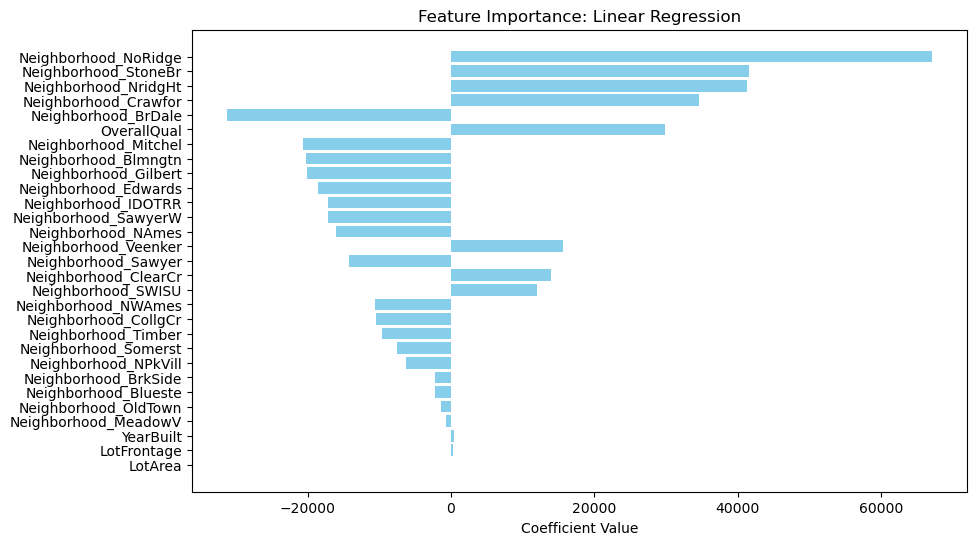

In [31]:
import matplotlib.pyplot as plt

coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values('abs_coef', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(
    coef_df_sorted['Feature'],
    coef_df_sorted['Coefficient'],
    color='skyblue'
)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance: Linear Regression')

plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


## Conclusion

- Overall quality is the strongest numeric predictor of house price.
- Neighborhood has a significant impact, justifying categorical encoding.
- Adding neighborhood information improved R² from ~0.70 to ~0.76.
- Linear regression provides an interpretable and strong baseline model.
